In [1]:
"""
Cleaned up version of the integration imports we need to actually run this code together.
"""

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [2]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) Local oscillator (LO) parameters:
FO  = 0                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 0          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO

# 2) Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011
paramPD.R = 1
paramPD.shotNoise = False
paramPD.thermalNoise = False
paramPD.currentSaturation = False
paramPD.bandwidthLimitation = False

# 3) Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs
paramFE.phaseImb = 0
paramFE.ampImb = 0
paramFE.timeSkew = 0



In [3]:
def simulate_phase_noise():

    # Tx 
    symbTx = symbolSource(paramSymb)      
    
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    sigTx = sigTx / np.max(np.abs(sigTx))

    # Keep the Tx laser ideal
    sigLO_tx = np.ones_like(sigTx)

    # Iqm
    sigTxo = iqm(sigLO_tx, mzmScale * sigTx, paramIQM)

    # -------------------------
    # 5) Set launched optical power
    # -------------------------
    # pnorm() normalizes the optical field so that mean(|E|^2)=1.
    # Then multiplying by sqrt(P) sets mean optical power to P (watts).
    # P_launch_W = dBm2W(P_launch_dBm)
    # sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)
    # Does not affect phase noise behaviour, can be kept in or removed

    # No Channel
    sigCh = sigTxo

    # Rx LO with phase noise
    paramLO.Ns = len(sigCh)

    sigLO_Rx = basicLaserModel(paramLO)

    # Coherent receiver
    sigRx = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    return sigRx

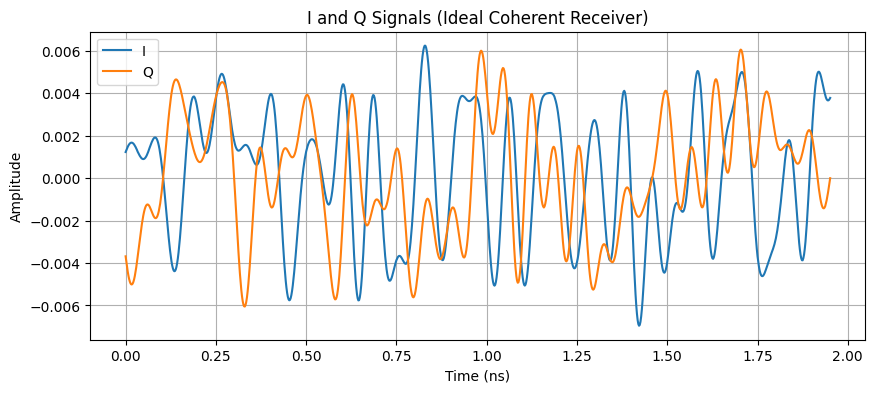

In [4]:
sigRx = simulate_phase_noise()

I_signal = sigRx.real
Q_signal = sigRx.imag

t = np.arange(len(I_signal)) / Fs

plt.figure(figsize=(10,4))
plt.plot(t[:1000]*1e9, I_signal[:1000], label='I')
plt.plot(t[:1000]*1e9, Q_signal[:1000], label='Q')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.title('I and Q Signals (Ideal Coherent Receiver)')
plt.legend()
plt.grid()
plt.show()

In [15]:
import numpy as np


def are_orthogonal(x, y, tol=1e-3):
    """
    Check if two signals are orthogonal within a given tolerance.

    Parameters:
        x (array-like): First signal
        y (array-like): Second signal
        tol (float): Tolerance for correlation magnitude

    Returns:
        (bool, float): (Orthogonal flag, correlation value)
    """
    corr = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
    return abs(corr) < tol, corr

# Example
sigRx = simulate_phase_noise()

I_signal = sigRx.real
Q_signal = sigRx.imag

orthogonal, corr_value = are_orthogonal(I_signal, Q_signal)
print(f"Orthogonal: {orthogonal}, Correlation: {corr_value}")

Orthogonal: False, Correlation: 0.00963171208027242


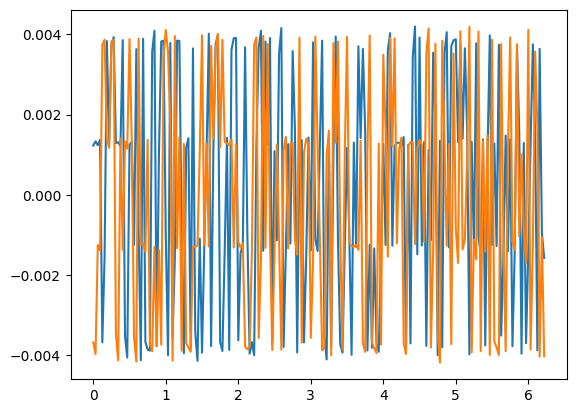

In [5]:
sig_sym = sigRx[::SpS]

I_signal = sig_sym.real
Q_signal = sig_sym.imag

t = np.arange(len(I_signal)) / Rs  # symbol time

plt.plot(t[:200]*1e9, I_signal[:200], label='I')
plt.plot(t[:200]*1e9, Q_signal[:200], label='Q')

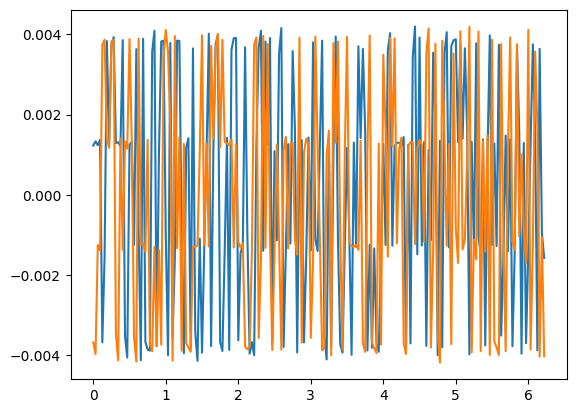

In [6]:
plt.plot(t[:200]*1e9, I_signal[:200], label='I')
plt.plot(t[:200]*1e9, Q_signal[:200], label='Q')

In [7]:
corr = np.corrcoef(I_signal, Q_signal)[0,1]
print("I/Q correlation:", corr)

I/Q correlation: 0.009513833710659746


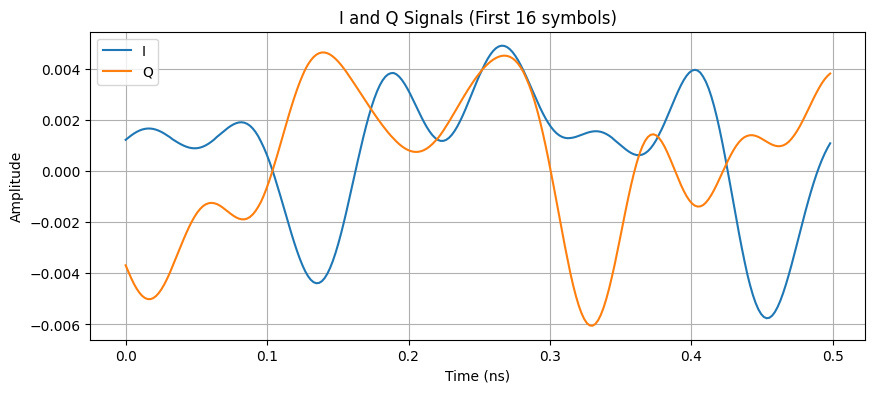

In [8]:
sigRx = simulate_phase_noise()

I_signal = sigRx.real
Q_signal = sigRx.imag
t = np.arange(len(I_signal)) / Fs

plt.figure(figsize=(10,4))

plt.plot(t[:256]*1e9, I_signal[:256], label='I')
plt.plot(t[:256]*1e9, Q_signal[:256], label='Q')

plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.title('I and Q Signals (First 16 symbols)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
norm_inner = np.sum(I_signal * Q_signal) / np.sqrt(np.sum(I_signal**2) * np.sum(Q_signal**2))
print("Normalized inner product:", norm_inner)

Normalized inner product: 0.00963171208027241


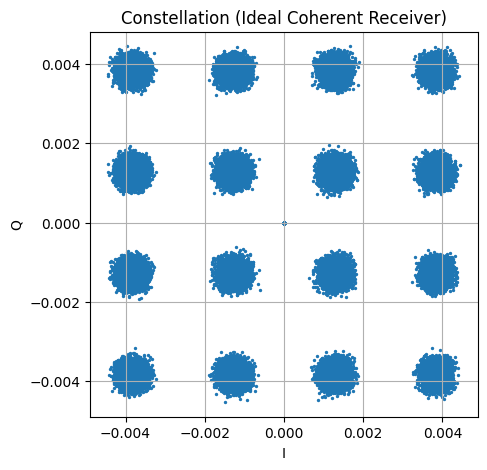

In [10]:
plt.figure(figsize=(5,5))
plt.scatter(I_signal[::SpS], Q_signal[::SpS], s=2)  # plot one sample per symbol
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Constellation (Ideal Coherent Receiver)')
plt.grid()
plt.axis('equal')
plt.show()

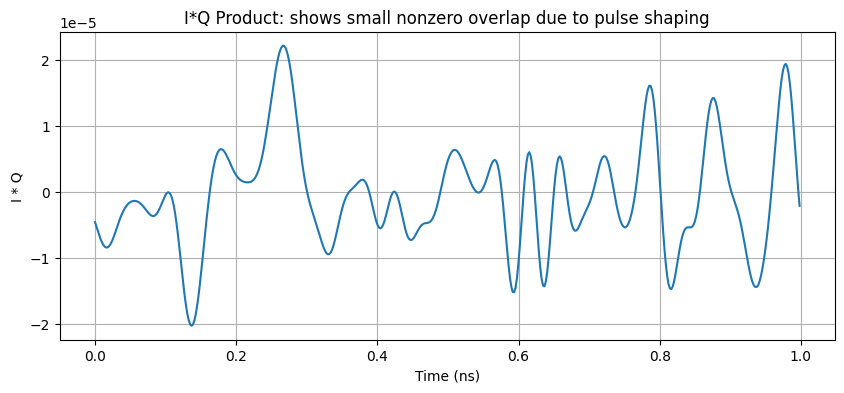

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Get product
product = I_signal[:512] * Q_signal[:512]  # first 32 symbols for clarity
t_plot = np.arange(len(product)) / Fs * 1e9  # ns

plt.figure(figsize=(10,4))
plt.plot(t_plot, product)
plt.xlabel('Time (ns)')
plt.ylabel('I * Q')
plt.title('I*Q Product: shows small nonzero overlap due to pulse shaping')
plt.grid(True)
plt.show()

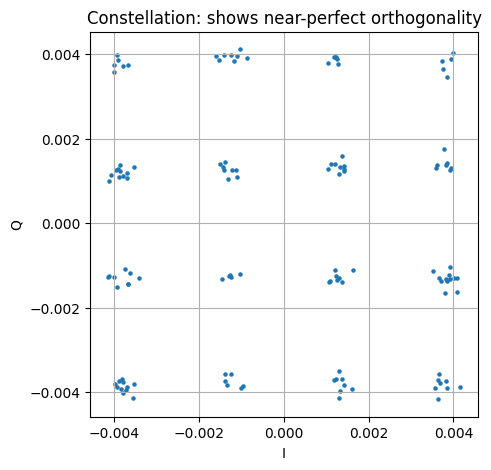

In [12]:
plt.figure(figsize=(5,5))
plt.scatter(I_signal[::SpS][:128], Q_signal[::SpS][:128], s=5)
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Constellation: shows near-perfect orthogonality')
plt.grid(True)
plt.axis('equal')
plt.show()